# 3. Алгоритм FP-Growth

**FP-Growth** — альтернатива Apriori, яка будує компактну структуру даних (FP-дерево) замість генерації кандидатів.  
Перевага: менше проходів по даних, вища швидкість на великих датасетах.  

**Мета:** знайти ті самі часті набори та правила, що й Apriori, і порівняти швидкість.

In [1]:
import sys
import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules

sys.path.insert(0, os.path.abspath('.'))
from src.config import MIN_SUPPORT, MIN_LIFT, BINNED_PATH, APRIORI_TIME_PATH

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print(f"MIN_SUPPORT = {MIN_SUPPORT}")
print(f"MIN_LIFT    = {MIN_LIFT}")
print(f"BINNED_PATH = {BINNED_PATH}")

MIN_SUPPORT = 0.03
MIN_LIFT    = 1.0
BINNED_PATH = F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\data\data_binned.csv


In [2]:
df = pd.read_csv(BINNED_PATH)
df_oh = pd.get_dummies(df, columns=df.columns.tolist(), dtype=bool, prefix_sep='_')

print(f"Дискретизовані дані: {df.shape}")
print(f"One-hot кодування:   {df_oh.shape}")
df_oh.head(3)

Дискретизовані дані: (89741, 7)
One-hot кодування:   (89741, 34)


,danceability_High,danceability_Low,danceability_Medium,energy_High,energy_Low,energy_Medium,valence_High,valence_Low,valence_Medium,acousticness_High,...,track_genre_bluegrass,track_genre_breakbeat,track_genre_cantopop,track_genre_chicago-house,track_genre_disney,track_genre_forro,track_genre_heavy-metal,track_genre_sleep,track_genre_study,track_genre_tango
0,True,False,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3.1 Пошук частих наборів (FP-Growth)

In [3]:
start = time.time()
frequent = fpgrowth(df_oh, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_time = round(time.time() - start, 4)

print(f"Знайдено {len(frequent)} частих наборів (min_support={MIN_SUPPORT})")
print(f"Час FP-Growth: {fpgrowth_time:.4f} сек")

frequent.sort_values('support', ascending=False).head(15)

Знайдено 855 частих наборів (min_support=0.03)
Час FP-Growth: 0.4181 сек


,support,itemsets
0,0.964442,frozenset({speechiness_Low})
16,0.833164,frozenset({track_genre_Other})
854,0.799222,"frozenset({track_genre_Other, speechiness_Low})"
1,0.731672,frozenset({loudness_Loud})
17,0.707581,"frozenset({loudness_Loud, speechiness_Low})"
18,0.627194,"frozenset({loudness_Loud, track_genre_Other})"
19,0.603994,"frozenset({loudness_Loud, track_genre_Other, s..."
2,0.595525,frozenset({acousticness_Low})
20,0.579278,"frozenset({speechiness_Low, acousticness_Low})"
6,0.573428,frozenset({danceability_Medium})


## 3.2 Генерація правил

In [4]:
rules = association_rules(frequent, metric='lift', min_threshold=MIN_LIFT, num_itemsets=len(frequent))
rules = rules.sort_values('lift', ascending=False)

print(f"Знайдено {len(rules)} правил (lift >= {MIN_LIFT})")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Знайдено 9930 правил (lift >= 1.0)


,antecedents,consequents,support,confidence,lift
9909,"frozenset({speechiness_Low, loudness_Quiet})","frozenset({energy_Low, valence_Low})",0.031223,0.763904,8.018893
9908,"frozenset({energy_Low, valence_Low})","frozenset({speechiness_Low, loudness_Quiet})",0.031223,0.327758,8.018893
9894,frozenset({loudness_Quiet}),"frozenset({energy_Low, valence_Low})",0.031401,0.753073,7.905199
9891,"frozenset({energy_Low, valence_Low})",frozenset({loudness_Quiet}),0.031401,0.329629,7.905199
9903,"frozenset({speechiness_Low, energy_Low, valenc...",frozenset({loudness_Quiet}),0.031223,0.329570,7.903767
9914,frozenset({loudness_Quiet}),"frozenset({speechiness_Low, energy_Low, valenc...",0.031223,0.748797,7.903767
6941,"frozenset({energy_Low, speechiness_Low, valenc...","frozenset({danceability_Low, acousticness_High})",0.034644,0.365679,7.865860
6944,"frozenset({danceability_Low, acousticness_High})","frozenset({energy_Low, speechiness_Low, valenc...",0.034644,0.745206,7.865860
6949,"frozenset({energy_Low, valence_Low})","frozenset({danceability_Low, speechiness_Low, ...",0.034644,0.363668,7.848955
6936,"frozenset({danceability_Low, speechiness_Low, ...","frozenset({energy_Low, valence_Low})",0.034644,0.747715,7.848955


## 3.3 Порівняння з Apriori

In [5]:
apriori_df = pd.read_csv(APRIORI_TIME_PATH)
apriori_t = apriori_df['time_sec'].iloc[0]

print(f"Час Apriori:   {apriori_t:.4f} сек")
print(f"Час FP-Growth: {fpgrowth_time:.4f} сек")

ratio = apriori_t / fpgrowth_time if fpgrowth_time > 0 else float('inf')
if fpgrowth_time < apriori_t:
    print(f"FP-Growth швидший у {ratio:.2f}x")
else:
    print(f"FP-Growth повільніший у {1/ratio:.2f}x")

comparison = pd.DataFrame([
    {'algorithm': 'Apriori',   'time_sec': round(apriori_t, 4)},
    {'algorithm': 'FP-Growth', 'time_sec': round(fpgrowth_time, 4)}
])
comparison

Час Apriori:   0.3781 сек
Час FP-Growth: 0.4181 сек
FP-Growth повільніший у 1.11x


,algorithm,time_sec
0,Apriori,0.3781
1,FP-Growth,0.4181


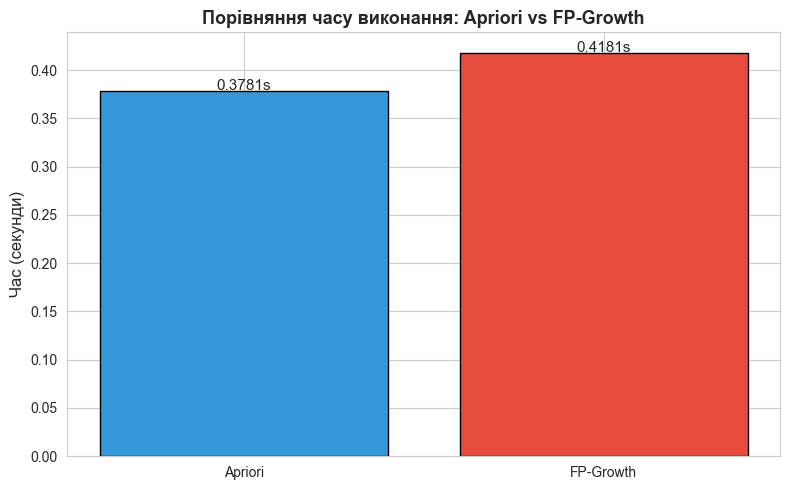

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
algos = ['Apriori', 'FP-Growth']
times = [apriori_t, fpgrowth_time]
bars = ax.bar(algos, times, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_ylabel('Час (секунди)', fontsize=12)
ax.set_title('Порівняння часу виконання: Apriori vs FP-Growth', fontsize=13, fontweight='bold')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{t:.4f}s', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
time_df = pd.DataFrame([
    {'algorithm': 'Apriori',   'time_sec': apriori_t},
    {'algorithm': 'FP-Growth', 'time_sec': fpgrowth_time}
])
time_df.to_csv(APRIORI_TIME_PATH, index=False)
print(f"Збережено оновлений файл: {APRIORI_TIME_PATH}")
time_df

Збережено оновлений файл: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\apriori_time.csv


,algorithm,time_sec
0,Apriori,0.3781
1,FP-Growth,0.4181


## 3.4 Розподіл розмірів наборів

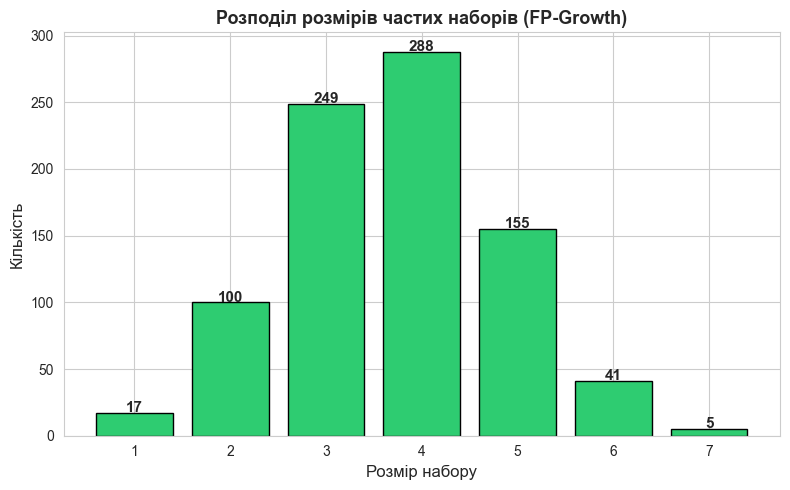

Розподіл:
  Розмір 1: 17 наборів
  Розмір 2: 100 наборів
  Розмір 3: 249 наборів
  Розмір 4: 288 наборів
  Розмір 5: 155 наборів
  Розмір 6: 41 наборів
  Розмір 7: 5 наборів


In [8]:
frequent['length'] = frequent['itemsets'].apply(len)
length_counts = frequent['length'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(length_counts.index, length_counts.values, color='#2ecc71', edgecolor='black')
ax.set_xlabel('Розмір набору', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)
ax.set_title('Розподіл розмірів частих наборів (FP-Growth)', fontsize=13, fontweight='bold')
ax.set_xticks(length_counts.index)
for x, y in zip(length_counts.index, length_counts.values):
    ax.text(x, y + 0.5, str(y), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Розподіл:")
for size, cnt in length_counts.items():
    print(f"  Розмір {size}: {cnt} наборів")

## Підсумок

**FP-Growth** знаходить **ідентичні** часті набори та асоціативні правила порівняно з Apriori, оскільки обидва алгоритми є точними (exact) методами пошуку.  
Різниця полягає у внутрішній реалізації:

- **Apriori** генерує набори-кандидати та перевіряє їх support на кожній ітерації.
- **FP-Growth** будує компактне FP-дерево та видобуває часті набори без генерації кандидатів.

На практиці FP-Growth демонструє перевагу у швидкості на великих датасетах зі значною кількістю транзакцій, оскільки потребує лише два проходи по даних. Для невеликих наборів різниця може бути незначною або навіть на користь Apriori через накладні витрати на побудову дерева.